# Data Cleaning

# Data Cleaning

Load & Inspeksi Awal

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('cleaned_nutrition_dataset_per100g.csv')

print(df.shape)
print(df.dtypes)
print(df.head())
print(df.describe())

(3454, 13)
Vitamin C (mg per 100g)       float64
Vitamin B11 (mg per 100g)     float64
Sodium (mg per 100g)          float64
Calcium (mg per 100g)         float64
Carbohydrates (g per 100g)    float64
food                           object
Iron (mg per 100g)            float64
Calories (kcal per 100g)      float64
Sugars (g per 100g)           float64
Dietary Fiber (g per 100g)    float64
Fat (g per 100g)              float64
Protein (g per 100g)          float64
food_normalized                object
dtype: object
   Vitamin C (mg per 100g)  Vitamin B11 (mg per 100g)  Sodium (mg per 100g)  \
0                    0.082                      0.086                 0.018   
1                    0.400                      0.005                 0.065   
2                    0.000                      0.000                 0.000   
3                    0.000                      0.000                 0.000   
4                    0.000                      0.000                 0.000   

   Cal

Cek Missing Values

In [4]:
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

df2 = pd.read_csv('Food_Nutrition_Dataset.csv')

# Opsi: isi dengan median (lebih robust dari mean untuk data nutrisi)
df2['iron'] = df2['iron'].fillna(df2['iron'].median())
df2['vitamin_c'] = df2['vitamin_c'].fillna(df2['vitamin_c'].median())

Vitamin C (mg per 100g)       0
Vitamin B11 (mg per 100g)     0
Sodium (mg per 100g)          0
Calcium (mg per 100g)         0
Carbohydrates (g per 100g)    0
food                          0
Iron (mg per 100g)            0
Calories (kcal per 100g)      0
Sugars (g per 100g)           0
Dietary Fiber (g per 100g)    0
Fat (g per 100g)              0
Protein (g per 100g)          0
food_normalized               0
dtype: int64

Total missing: 0


Deteksi & Handle Outlier

In [5]:
from scipy import stats

cols_numeric = ['Calories (kcal per 100g)', 'Protein (g per 100g)', 'Fat (g per 100g)', 'Carbohydrates (g per 100g)']

for col in cols_numeric:
  z_scores = np.abs(stats.zscore(df[col]))
  outliers = df[z_scores > 3]
  print(f"{col}: {len(outliers)} outlier rows")
  print(outliers[['food', col]].head(3))
  print()

Calories (kcal per 100g): 33 outlier rows
                 food  Calories (kcal per 100g)
3   menhaden fish oil                    1966.0
19  nutmeg butter oil                    1927.0
32        sheanut oil                    1927.0

Protein (g per 100g): 29 outlier rows
                               food  Protein (g per 100g)
730    profeel proteiinirahka valio                 175.0
1817  beef under blade steak cooked                 140.8
1825             veal leg round raw                  95.2

Fat (g per 100g): 32 outlier rows
                 food  Fat (g per 100g)
3   menhaden fish oil             218.0
19  nutmeg butter oil             218.0
32        sheanut oil             218.0

Carbohydrates (g per 100g): 88 outlier rows
               food  Carbohydrates (g per 100g)
59  chinese noodles                       111.9
85      puff pastry                       112.0
90         tortilla                        98.4



## Kesimpulan Data Cleaning

**Dataset 1 (cleaned_nutrition_dataset_per100g.csv)**
- Shape: 3454 baris × 13 kolom
- Missing values: 0 (tidak ada)
- Outlier: Ditemukan pada kolom Calories (33), Protein (29), Fat (32), Carbohydrates (88)
- Keputusan: Outlier DIPERTAHANKAN karena valid secara domain
  (contoh: minyak ikan memang tinggi kalori, suplemen protein memang tinggi protein)

**Dataset 2 (Food_Nutrition_Dataset.csv)**
- Shape: 205 baris × 8 kolom  
- Missing values: iron (2), vitamin_c (3) → diisi dengan nilai median
- Outlier: tidak dideteksi (dataset kecil, akan digunakan sebagai pelengkap)

# EDA

Statistik Deskriptif

In [6]:
# Cell 1 - Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Setting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

df = pd.read_csv('cleaned_nutrition_dataset_per100g.csv')
print("Dataset shape:", df.shape)
df.describe().round(2)

Dataset shape: (3454, 13)


,Vitamin C (mg per 100g),Vitamin B11 (mg per 100g),Sodium (mg per 100g),Calcium (mg per 100g),Carbohydrates (g per 100g),Iron (mg per 100g),Calories (kcal per 100g),Sugars (g per 100g),Dietary Fiber (g per 100g),Fat (g per 100g),Protein (g per 100g)
count,3454.00,3454.00,3454.00,3454.00,3454.00,3454.00,3454.00,3454.00,3454.00,3454.00,3454.00
mean,9.50,11.45,141.44,53.95,18.72,1.63,227.59,5.69,2.16,12.01,10.82
std,70.39,33.85,973.17,103.34,26.23,4.38,336.28,13.14,4.75,26.73,27.25
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,0.06,4.65,1.70,0.20,60.05,0.00,0.00,0.50,1.26
50%,0.30,0.08,0.20,21.94,9.11,0.70,134.42,0.92,0.71,4.11,3.80
75%,5.38,4.33,21.37,60.60,26.40,1.60,285.01,5.21,2.33,12.50,9.24
max,3872.00,550.52,14174.59,1283.50,390.20,121.20,6077.00,291.50,76.50,550.70,560.30


Distribusi Nutrisi Utama

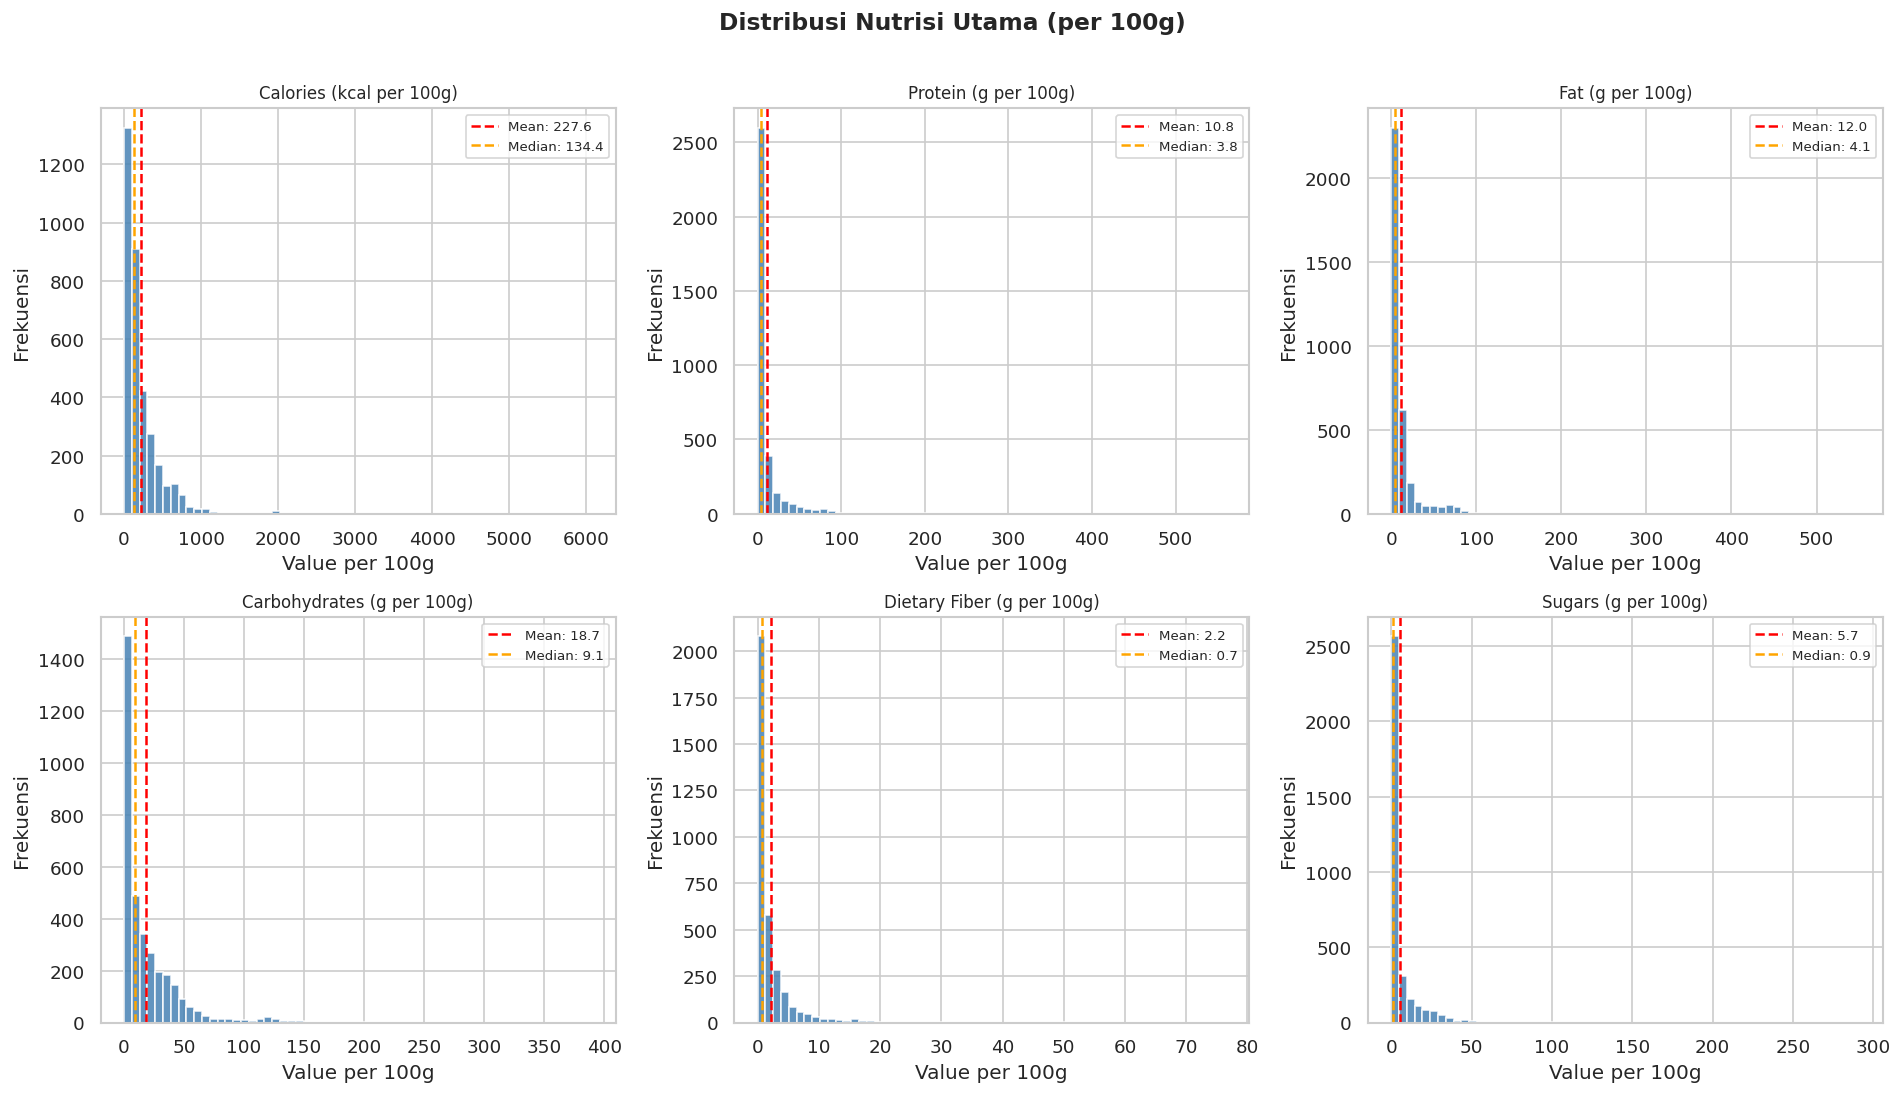

In [7]:
# Cell 2 - Histogram distribusi 6 nutrisi utama
nutrisi_utama = [
    'Calories (kcal per 100g)',
    'Protein (g per 100g)',
    'Fat (g per 100g)',
    'Carbohydrates (g per 100g)',
    'Dietary Fiber (g per 100g)',
    'Sugars (g per 100g)'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(nutrisi_utama):
    axes[i].hist(df[col], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df[col].median():.1f}')
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Value per 100g')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend(fontsize=8)

plt.suptitle('Distribusi Nutrisi Utama (per 100g)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distribusi_nutrisi.png', bbox_inches='tight')
plt.show()

Heatmap Korelasi

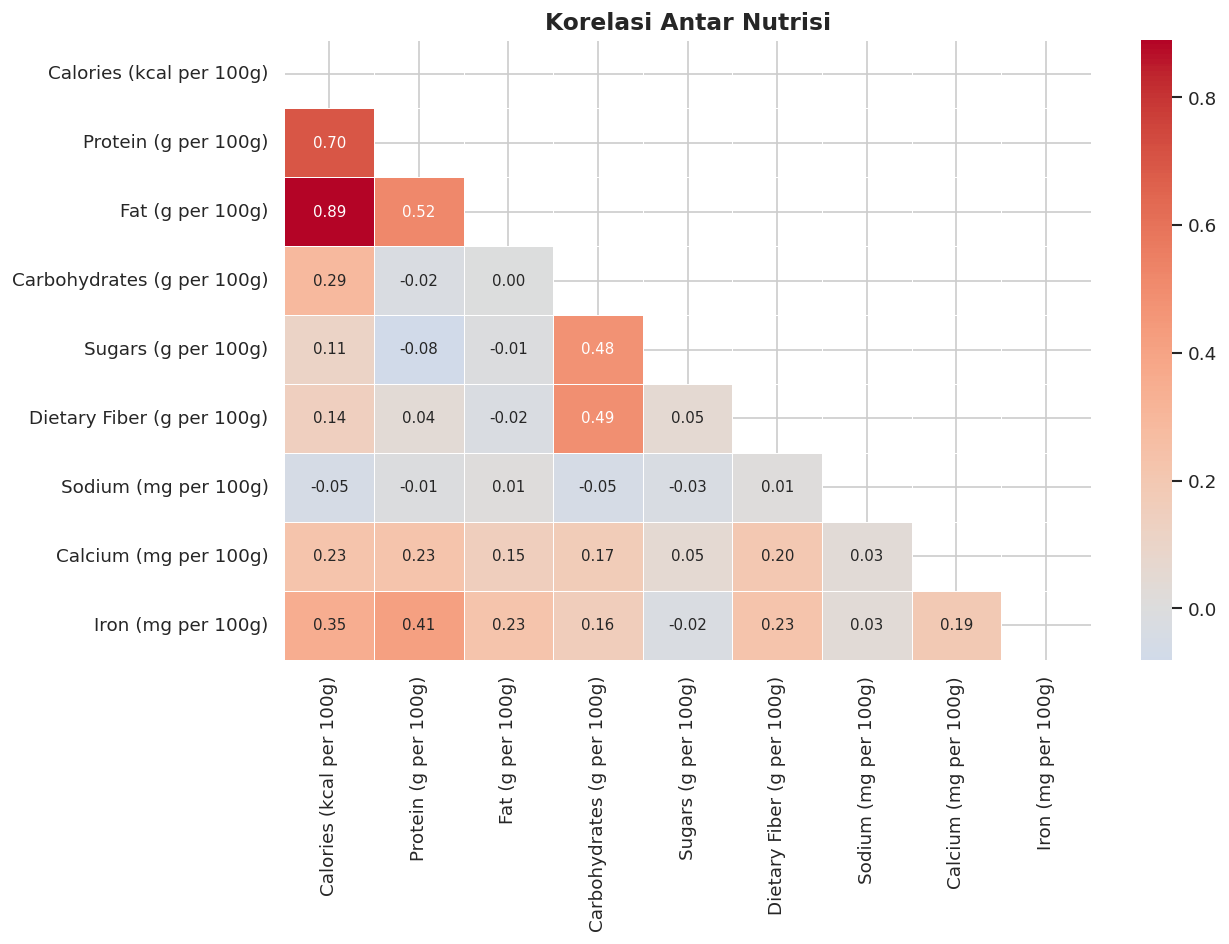

In [8]:
# Cell 3 - Korelasi antar nutrisi
kolom_korelasi = [
    'Calories (kcal per 100g)',
    'Protein (g per 100g)',
    'Fat (g per 100g)',
    'Carbohydrates (g per 100g)',
    'Sugars (g per 100g)',
    'Dietary Fiber (g per 100g)',
    'Sodium (mg per 100g)',
    'Calcium (mg per 100g)',
    'Iron (mg per 100g)'
]

corr_matrix = df[kolom_korelasi].corr().round(2)

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # sembunyikan segitiga atas
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={"size": 9}
)
plt.title('Korelasi Antar Nutrisi', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('korelasi_nutrisi.png', bbox_inches='tight')
plt.show()

Profil Kalori

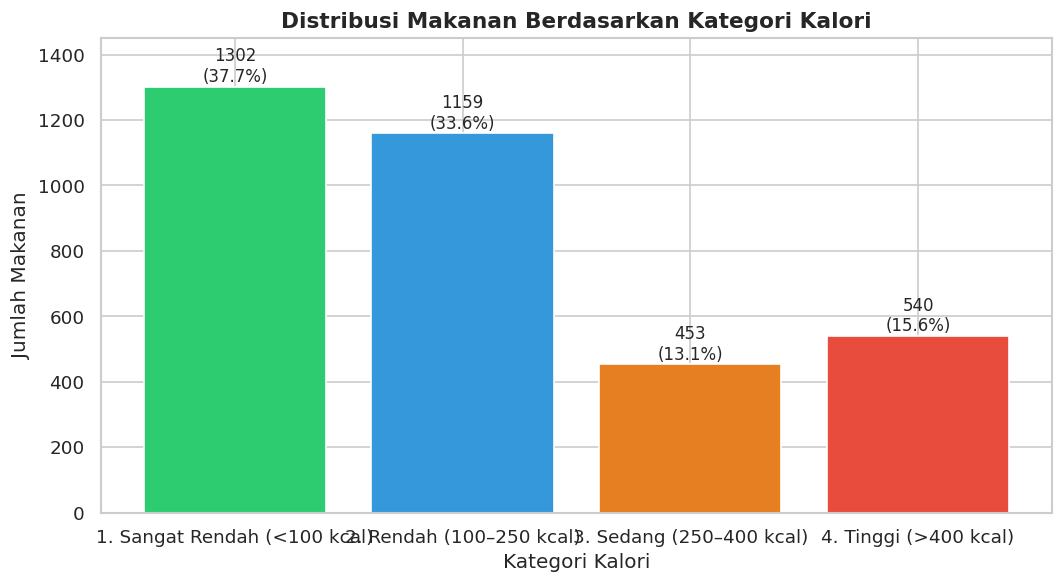

kalori_kategori
1. Sangat Rendah (<100 kcal)    1302
2. Rendah (100–250 kcal)        1159
3. Sedang (250–400 kcal)         453
4. Tinggi (>400 kcal)            540
Name: count, dtype: int64


In [9]:
# Cell 4 - Kategorisasi kalori
def kategori_kalori(kal):
    if kal < 100:   return '1. Sangat Rendah (<100 kcal)'
    elif kal < 250: return '2. Rendah (100–250 kcal)'
    elif kal < 400: return '3. Sedang (250–400 kcal)'
    else:           return '4. Tinggi (>400 kcal)'

df['kalori_kategori'] = df['Calories (kcal per 100g)'].apply(kategori_kalori)

counts = df['kalori_kategori'].value_counts().sort_index()

plt.figure(figsize=(9, 5))
bars = plt.bar(counts.index, counts.values, color=['#2ecc71','#3498db','#e67e22','#e74c3c'], edgecolor='white')

for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
             f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)

plt.title('Distribusi Makanan Berdasarkan Kategori Kalori', fontsize=13, fontweight='bold')
plt.xlabel('Kategori Kalori')
plt.ylabel('Jumlah Makanan')
plt.ylim(0, counts.max() + 150)
plt.tight_layout()
plt.savefig('profil_kalori.png', bbox_inches='tight')
plt.show()

print(counts)

Top Makanan per Nutrisi

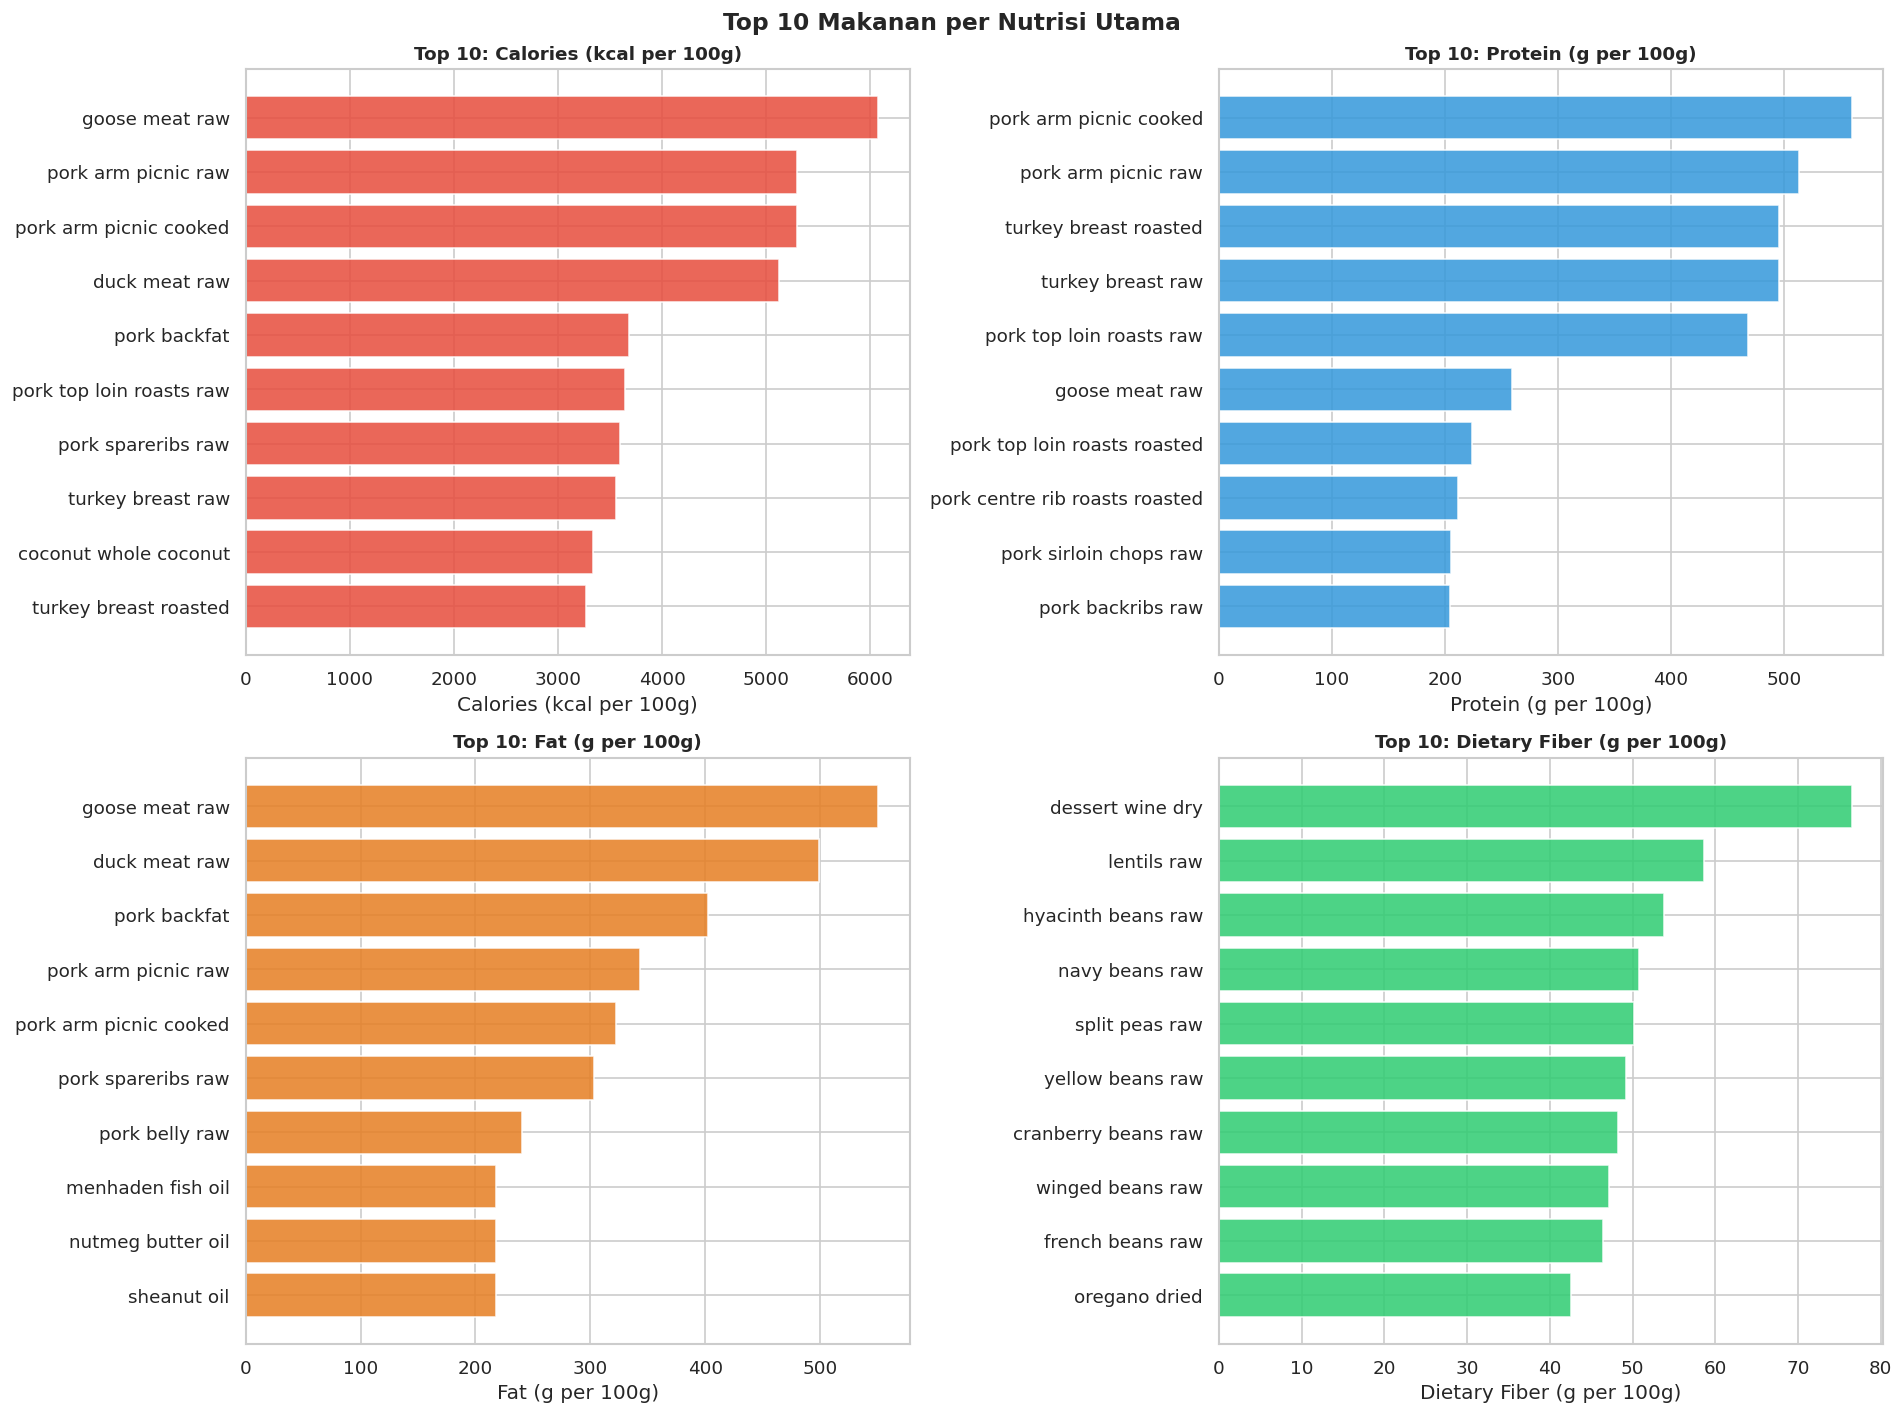

In [10]:
# Cell 5 - Top 10 makanan tertinggi per nutrisi kunci
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

nutrisi_top = {
    'Calories (kcal per 100g)': axes[0, 0],
    'Protein (g per 100g)':     axes[0, 1],
    'Fat (g per 100g)':         axes[1, 0],
    'Dietary Fiber (g per 100g)': axes[1, 1]
}

colors = ['#e74c3c', '#3498db', '#e67e22', '#2ecc71']

for (col, ax), color in zip(nutrisi_top.items(), colors):
    top10 = df.nlargest(10, col)[['food', col]].reset_index(drop=True)
    top10['food_short'] = top10['food'].str[:35]  # potong nama panjang
    ax.barh(top10['food_short'][::-1], top10[col][::-1], color=color, alpha=0.85)
    ax.set_title(f'Top 10: {col}', fontsize=11, fontweight='bold')
    ax.set_xlabel(col)

plt.suptitle('Top 10 Makanan per Nutrisi Utama', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top10_nutrisi.png', bbox_inches='tight')
plt.show()

Boxplot Nutrisi (Ringkasan)

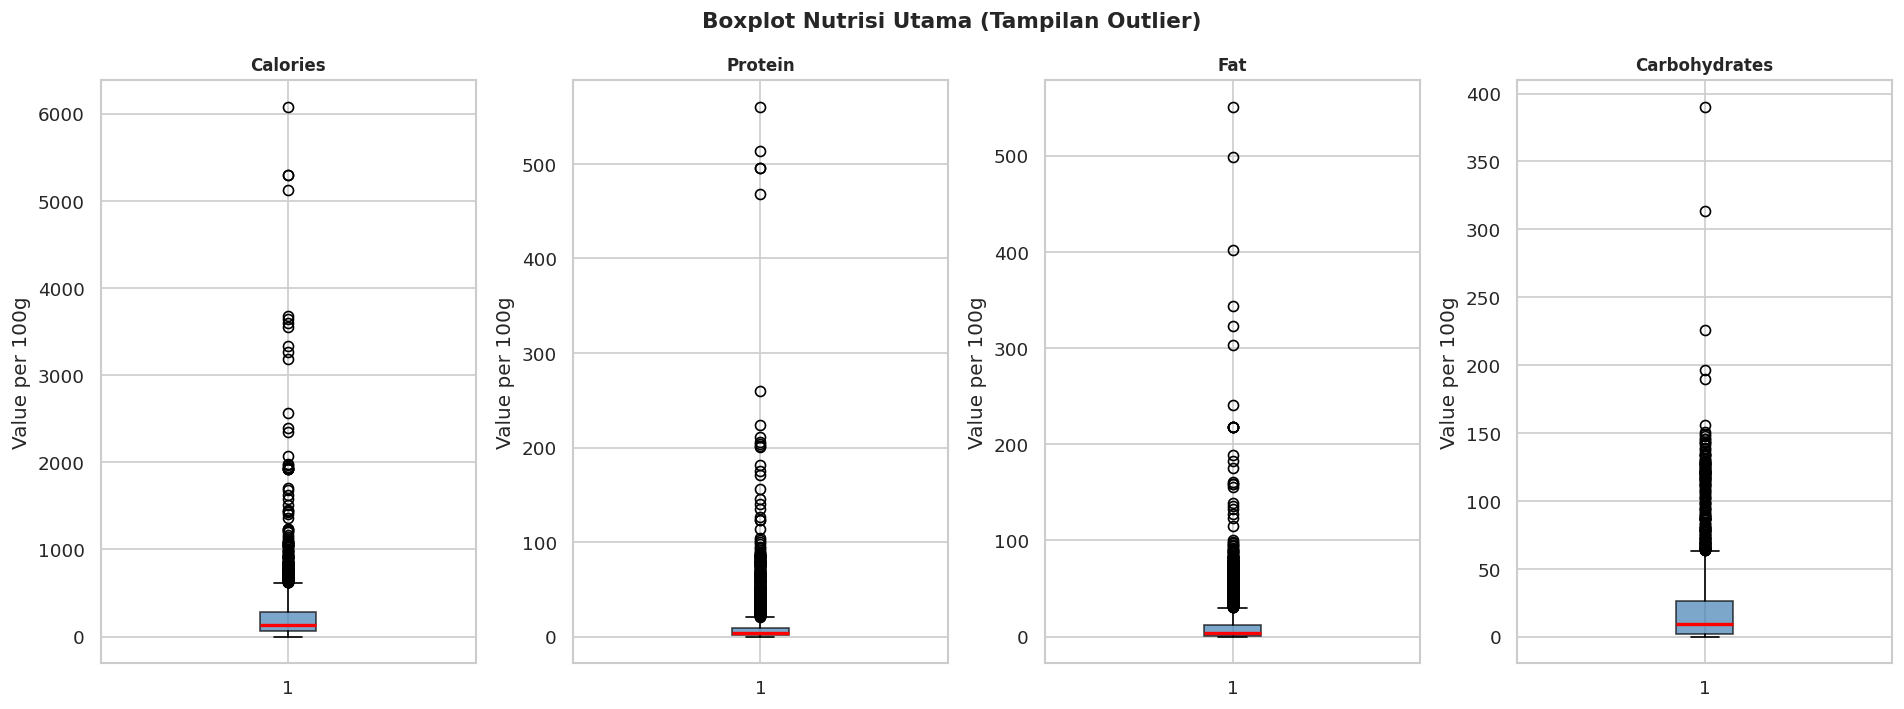

In [11]:
# Cell 6 - Boxplot untuk lihat sebaran & outlier secara visual
fig, axes = plt.subplots(1, 4, figsize=(16, 6))

boxplot_cols = [
    'Calories (kcal per 100g)',
    'Protein (g per 100g)',
    'Fat (g per 100g)',
    'Carbohydrates (g per 100g)'
]

for ax, col in zip(axes, boxplot_cols):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.7),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(col.split('(')[0].strip(), fontsize=10, fontweight='bold')
    ax.set_ylabel('Value per 100g')

plt.suptitle('Boxplot Nutrisi Utama (Tampilan Outlier)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplot_nutrisi.png', bbox_inches='tight')
plt.show()

Kesimpulan EDA

In [12]:
# Cell 7 - Print ringkasan insight
print("=" * 55)
print("         RINGKASAN INSIGHT EDA")
print("=" * 55)

print(f"\n📌 Total item makanan   : {len(df):,}")
print(f"📌 Total fitur nutrisi  : {df.shape[1] - 2} kolom nutrisi\n")

for col in nutrisi_utama:
    print(f"▸ {col.split('(')[0].strip():<22} "
          f"mean={df[col].mean():.1f}, "
          f"median={df[col].median():.1f}, "
          f"max={df[col].max():.1f}")

print(f"\n📌 Distribusi kategori kalori:")
for k, v in df['kalori_kategori'].value_counts().sort_index().items():
    print(f"   {k}: {v} items ({v/len(df)*100:.1f}%)")

         RINGKASAN INSIGHT EDA

📌 Total item makanan   : 3,454
📌 Total fitur nutrisi  : 12 kolom nutrisi

▸ Calories               mean=227.6, median=134.4, max=6077.0
▸ Protein                mean=10.8, median=3.8, max=560.3
▸ Fat                    mean=12.0, median=4.1, max=550.7
▸ Carbohydrates          mean=18.7, median=9.1, max=390.2
▸ Dietary Fiber          mean=2.2, median=0.7, max=76.5
▸ Sugars                 mean=5.7, median=0.9, max=291.5

📌 Distribusi kategori kalori:
   1. Sangat Rendah (<100 kcal): 1302 items (37.7%)
   2. Rendah (100–250 kcal): 1159 items (33.6%)
   3. Sedang (250–400 kcal): 453 items (13.1%)
   4. Tinggi (>400 kcal): 540 items (15.6%)
